# Data Exploration

April 15th 2026 

In [1]:
Data_path = "/Users/aniruddh/Library/CloudStorage/Box-Box/tahoe100-pseudo"



In [2]:
from pathlib import Path

import anndata as ad
import pandas as pd
from IPython.display import display

data_path = Path(Data_path)
h5ad_files = sorted(data_path.glob("*.h5ad"))

file_summaries = []
for path in h5ad_files:
    backed_adata = ad.read_h5ad(path, backed="r")
    file_summaries.append(
        {
            "file_name": path.name,
            "size_mb": round(path.stat().st_size / (1024 ** 2), 1),
            "n_obs": backed_adata.n_obs,
            "n_vars": backed_adata.n_vars,
        }
    )
    backed_adata.file.close()

files_df = pd.DataFrame(file_summaries)

print(f"Found {len(h5ad_files)} .h5ad files in {data_path}")
display(files_df)


Found 24 .h5ad files in /Users/aniruddh/Library/CloudStorage/Box-Box/tahoe100-pseudo


,file_name,size_mb,n_obs,n_vars
0,CVCL_0023.h5ad,321.0,1328,62710
1,CVCL_0028.h5ad,280.3,1158,62710
2,CVCL_0069.h5ad,317.6,1314,62710
3,CVCL_0099.h5ad,310.4,1284,62710
4,CVCL_0131.h5ad,320.7,1327,62710
5,CVCL_0152.h5ad,320.7,1327,62710
6,CVCL_0179.h5ad,320.0,1324,62710
7,CVCL_0218.h5ad,316.4,1309,62710
8,CVCL_0292.h5ad,312.8,1294,62710
9,CVCL_0293.h5ad,320.7,1327,62710


In [3]:
sample_file = h5ad_files[0]
adata = ad.read_h5ad(sample_file, backed="r")

summary_df = pd.DataFrame(
    {
        "value": [
            sample_file.name,
            adata.n_obs,
            adata.n_vars,
            list(adata.obs.columns),
            list(adata.var.columns),
        ]
    },
    index=["selected_file", "n_obs", "n_vars", "obs_columns", "var_columns"],
)

display(summary_df)


,value
selected_file,CVCL_0023.h5ad
n_obs,1328
n_vars,62710
obs_columns,"[drug, drugname_drugconc, sample, plate, repli..."
var_columns,[]


The `.obs` table holds row-level metadata for each pseudobulk sample, `.var` holds gene-level metadata, and `X` is the expression matrix. The cell below previews all three as pandas DataFrames.

In [4]:
obs_preview = adata.obs.reset_index().head(10)
var_preview = adata.var.reset_index().head(10)

expr_preview = pd.DataFrame(
    adata.X[:5, :5],
    index=adata.obs_names[:5],
    columns=adata.var_names[:5],
)
expr_preview.index.name = adata.obs.index.name or "obs_name"
expr_preview.columns.name = adata.var.index.name or "var_name"

display(obs_preview)
display(var_preview)
display(expr_preview)


,pseudobulk_group,drug,drugname_drugconc,sample,plate,replicate_id,n_cells_total,n_complete_blocks,n_cells_used,n_cells_dropped
0,"drug=[('(R)-Verapamil (hydrochloride)', 0.05, ...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 0.05, 'uM')]",smp_1799,plate4,smp_1799,2668,13,2668,0
1,"drug=[('(R)-Verapamil (hydrochloride)', 0.5, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 0.5, 'uM')]",smp_1895,plate5,smp_1895,1503,7,1503,0
2,"drug=[('(R)-Verapamil (hydrochloride)', 5.0, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 5.0, 'uM')]",smp_1991,plate6,smp_1991,2350,11,2350,0
3,"drug=[('(R)-Verapamil (hydrochloride)', 5.0, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 5.0, 'uM')]",smp_2759,plate14,smp_2759,2256,11,2256,0
4,"drug=[('(S)-Crizotinib', 0.05, 'uM')]|sample=s...",(S)-Crizotinib,"[('(S)-Crizotinib', 0.05, 'uM')]",smp_2100,plate7,smp_2100,2396,11,2396,0
5,"drug=[('(S)-Crizotinib', 0.5, 'uM')]|sample=sm...",(S)-Crizotinib,"[('(S)-Crizotinib', 0.5, 'uM')]",smp_2196,plate8,smp_2196,2203,11,2203,0
6,"drug=[('(S)-Crizotinib', 5.0, 'uM')]|sample=sm...",(S)-Crizotinib,"[('(S)-Crizotinib', 5.0, 'uM')]",smp_2292,plate9,smp_2292,1153,5,1153,0
7,"drug=[('18β-Glycyrrhetinic acid', 0.05, 'uM')]...",18β-Glycyrrhetinic acid,"[('18β-Glycyrrhetinic acid', 0.05, 'uM')]",smp_1812,plate4,smp_1812,1767,8,1767,0
8,"drug=[('18β-Glycyrrhetinic acid', 0.5, 'uM')]|...",18β-Glycyrrhetinic acid,"[('18β-Glycyrrhetinic acid', 0.5, 'uM')]",smp_1908,plate5,smp_1908,1086,5,1086,0
9,"drug=[('18β-Glycyrrhetinic acid', 5.0, 'uM')]|...",18β-Glycyrrhetinic acid,"[('18β-Glycyrrhetinic acid', 5.0, 'uM')]",smp_2004,plate6,smp_2004,1139,5,1139,0


,ensembl_id
0,ENSG00000000003
1,ENSG00000000005
2,ENSG00000000419
3,ENSG00000000457
4,ENSG00000000460
5,ENSG00000000938
6,ENSG00000000971
7,ENSG00000001036
8,ENSG00000001084
9,ENSG00000001167


ensembl_id,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460
pseudobulk_group,,,,,
"drug=[('(R)-Verapamil (hydrochloride)', 0.05, 'uM')]|sample=smp_1799|plate=plate4",2.323838,0.000000,19.715143,3.823088,6.071964
"drug=[('(R)-Verapamil (hydrochloride)', 0.5, 'uM')]|sample=smp_1895|plate=plate5",2.661344,0.000000,18.097139,2.661344,4.790419
"drug=[('(R)-Verapamil (hydrochloride)', 5.0, 'uM')]|sample=smp_1991|plate=plate6",2.638298,0.000000,27.063829,5.106383,8.510638
"drug=[('(R)-Verapamil (hydrochloride)', 5.0, 'uM')]|sample=smp_2759|plate=plate14",2.659575,0.000000,26.329786,5.851064,9.219858
"drug=[('(S)-Crizotinib', 0.05, 'uM')]|sample=smp_2100|plate=plate7",4.257095,0.083472,40.150249,2.587646,9.181970


In [5]:
obs_preview = adata.obs.reset_index()
obs_preview

,pseudobulk_group,drug,drugname_drugconc,sample,plate,replicate_id,n_cells_total,n_complete_blocks,n_cells_used,n_cells_dropped
0,"drug=[('(R)-Verapamil (hydrochloride)', 0.05, ...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 0.05, 'uM')]",smp_1799,plate4,smp_1799,2668,13,2668,0
1,"drug=[('(R)-Verapamil (hydrochloride)', 0.5, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 0.5, 'uM')]",smp_1895,plate5,smp_1895,1503,7,1503,0
2,"drug=[('(R)-Verapamil (hydrochloride)', 5.0, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 5.0, 'uM')]",smp_1991,plate6,smp_1991,2350,11,2350,0
3,"drug=[('(R)-Verapamil (hydrochloride)', 5.0, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 5.0, 'uM')]",smp_2759,plate14,smp_2759,2256,11,2256,0
4,"drug=[('(S)-Crizotinib', 0.05, 'uM')]|sample=s...",(S)-Crizotinib,"[('(S)-Crizotinib', 0.05, 'uM')]",smp_2100,plate7,smp_2100,2396,11,2396,0
...,...,...,...,...,...,...,...,...,...,...
1323,"drug=[('vincristine', 0.5, 'uM')]|sample=smp_1...",vincristine,"[('vincristine', 0.5, 'uM')]",smp_1674,plate2,smp_1674,930,4,930,0
1324,"drug=[('vincristine', 5.0, 'uM')]|sample=smp_1...",vincristine,"[('vincristine', 5.0, 'uM')]",smp_1770,plate3,smp_1770,665,3,665,0
1325,"drug=[('γ-Oryzanol', 0.05, 'uM')]|sample=smp_2...",γ-Oryzanol,"[('γ-Oryzanol', 0.05, 'uM')]",smp_2430,plate10,smp_2430,2584,12,2584,0
1326,"drug=[('γ-Oryzanol', 0.5, 'uM')]|sample=smp_25...",γ-Oryzanol,"[('γ-Oryzanol', 0.5, 'uM')]",smp_2526,plate11,smp_2526,1663,8,1663,0


In [6]:
adata.file.close()


## Drop `plate14` Across All Files

This block scans every `.h5ad` file in backed mode, counts how many pseudobulk rows belong to `plate14`, and stores a keep-mask for the next filtering step.

In [7]:
plate14_keep_masks = {}
plate14_drop_records = []

for path in h5ad_files:
    backed_adata = ad.read_h5ad(path, backed="r")
    if "plate" not in backed_adata.obs.columns:
        backed_adata.file.close()
        raise KeyError(f"Expected a 'plate' column in {path.name}")

    plate_values = backed_adata.obs["plate"].astype(str)
    drop_mask = plate_values.eq("plate14").to_numpy()
    keep_mask = ~drop_mask

    plate14_keep_masks[path.name] = keep_mask
    plate14_drop_records.append(
        {
            "file_name": path.name,
            "n_obs_before": int(backed_adata.n_obs),
            "plate14_dropped": int(drop_mask.sum()),
            "n_obs_after": int(keep_mask.sum()),
        }
    )
    backed_adata.file.close()

plate14_drop_summary_df = pd.DataFrame(plate14_drop_records)
total_plate14_dropped = int(plate14_drop_summary_df["plate14_dropped"].sum())

print(f"Total plate14 rows dropped across all files: {total_plate14_dropped}")
display(plate14_drop_summary_df)


Total plate14 rows dropped across all files: 2262


,file_name,n_obs_before,plate14_dropped,n_obs_after
0,CVCL_0023.h5ad,1328,95,1233
1,CVCL_0028.h5ad,1158,91,1067
2,CVCL_0069.h5ad,1314,93,1221
3,CVCL_0099.h5ad,1284,92,1192
4,CVCL_0131.h5ad,1327,95,1232
5,CVCL_0152.h5ad,1327,95,1232
6,CVCL_0179.h5ad,1324,95,1229
7,CVCL_0218.h5ad,1309,95,1214
8,CVCL_0292.h5ad,1294,95,1199
9,CVCL_0293.h5ad,1327,95,1232


## Build The Protein-Coding Ensembl ID Set

The `.h5ad` files are indexed by Ensembl IDs, while `outputs/protein_coding_genes.txt` stores gene symbols. This block reads the local Tahoe gene metadata cache and converts the saved protein-coding symbols into a canonical Ensembl ID keep-set.

In [8]:
import pyarrow as pa
import pyarrow.ipc as ipc

project_root_candidates = [Path.cwd(), Path.cwd().parent]
protein_gene_list_path = next(
    (
        candidate / "outputs" / "protein_coding_genes.txt"
        for candidate in project_root_candidates
        if (candidate / "outputs" / "protein_coding_genes.txt").exists()
    ),
    None,
)
if protein_gene_list_path is None:
    raise FileNotFoundError("Could not find outputs/protein_coding_genes.txt from the current working directory.")

gene_metadata_candidates = sorted(
    Path.home().glob(
        ".cache/huggingface/datasets/vevotx___tahoe-100_m/gene_metadata/0.0.0/*/tahoe-100_m-train.arrow"
    )
)
if not gene_metadata_candidates:
    raise FileNotFoundError("Could not find cached Tahoe gene_metadata Arrow file in the Hugging Face cache.")

gene_metadata_arrow_path = gene_metadata_candidates[-1]

with pa.memory_map(str(gene_metadata_arrow_path), "r") as source:
    try:
        gene_metadata_table = ipc.open_file(source).read_all()
    except pa.ArrowInvalid:
        source.seek(0)
        gene_metadata_table = ipc.open_stream(source).read_all()

gene_metadata_df = gene_metadata_table.to_pandas()
gene_metadata_df["ensembl_core"] = gene_metadata_df["ensembl_id"].astype(str).str.split(".").str[0]

protein_coding_gene_symbols = [
    line.strip()
    for line in protein_gene_list_path.read_text().splitlines()
    if line.strip()
]

protein_coding_metadata_df = gene_metadata_df.loc[
    gene_metadata_df["gene_symbol"].isin(protein_coding_gene_symbols),
    ["gene_symbol", "ensembl_id", "ensembl_core"],
].drop_duplicates()

protein_coding_ensembl_ids = pd.Index(
    sorted(protein_coding_metadata_df["ensembl_core"].unique()),
    name="ensembl_id",
)
matched_symbols = int(protein_coding_metadata_df["gene_symbol"].nunique())
missing_symbols = sorted(set(protein_coding_gene_symbols) - set(protein_coding_metadata_df["gene_symbol"]))

protein_coding_summary_df = pd.DataFrame(
    {
        "value": [
            str(protein_gene_list_path),
            str(gene_metadata_arrow_path),
            len(protein_coding_ensembl_ids),
            matched_symbols,
            len(missing_symbols),
        ]
    },
    index=[
        "protein_gene_list_path",
        "gene_metadata_arrow_path",
        "protein_gene_count",
        "matched_symbols",
        "missing_symbols",
    ],
)

display(protein_coding_summary_df)
if missing_symbols:
    print("First missing symbols:", missing_symbols[:10])


,value
protein_gene_list_path,/Users/aniruddh/Library/CloudStorage/OneDrive-...
gene_metadata_arrow_path,/Users/aniruddh/.cache/huggingface/datasets/ve...
protein_gene_count,20061
matched_symbols,20061
missing_symbols,0


## Filter All Files In Memory

This block reads each file one at a time, applies the stored `plate14` keep-mask, then restricts the expression matrix to protein-coding genes only.

In [9]:
filtered_adatas = {}
filtered_shape_records = []

for path in h5ad_files:
    adata_full = ad.read_h5ad(path)
    row_mask = plate14_keep_masks[path.name]
    var_ensembl_core = pd.Index(adata_full.var_names.astype(str)).str.split(".").str[0]
    col_mask = var_ensembl_core.isin(protein_coding_ensembl_ids)

    filtered_adata = adata_full[row_mask, col_mask].copy()
    filtered_adatas[path.name] = filtered_adata
    filtered_shape_records.append(
        {
            "file_name": path.name,
            "n_obs_before": int(adata_full.n_obs),
            "n_obs_after": int(filtered_adata.n_obs),
            "n_vars_before": int(adata_full.n_vars),
            "n_vars_after": int(filtered_adata.n_vars),
        }
    )
    del adata_full

filtered_shapes_df = pd.DataFrame(filtered_shape_records)
display(filtered_shapes_df)


,file_name,n_obs_before,n_obs_after,n_vars_before,n_vars_after
0,CVCL_0023.h5ad,1328,1233,62710,20061
1,CVCL_0028.h5ad,1158,1067,62710,20061
2,CVCL_0069.h5ad,1314,1221,62710,20061
3,CVCL_0099.h5ad,1284,1192,62710,20061
4,CVCL_0131.h5ad,1327,1232,62710,20061
5,CVCL_0152.h5ad,1327,1232,62710,20061
6,CVCL_0179.h5ad,1324,1229,62710,20061
7,CVCL_0218.h5ad,1309,1214,62710,20061
8,CVCL_0292.h5ad,1294,1199,62710,20061
9,CVCL_0293.h5ad,1327,1232,62710,20061


## Validate The Filtered Results

In [10]:
assert int(plate14_drop_summary_df["plate14_dropped"].sum()) == 2262
assert len(protein_coding_ensembl_ids) == 20061
assert len(missing_symbols) == 0
assert all((~filtered_adata.obs["plate"].eq("plate14")).all() for filtered_adata in filtered_adatas.values())
assert all(filtered_adata.n_vars == 20061 for filtered_adata in filtered_adatas.values())
assert filtered_shapes_df["n_vars_after"].nunique() == 1
assert int(filtered_shapes_df["n_vars_after"].iloc[0]) == 20061

print("All validation checks passed.")


All validation checks passed.


## Inspect One Filtered File

In [11]:
selected_filtered_file = sorted(filtered_adatas)[0]
selected_filtered_adata = filtered_adatas[selected_filtered_file]

filtered_obs_preview = selected_filtered_adata.obs.reset_index().head(10)
filtered_var_preview = selected_filtered_adata.var.reset_index().head(10)
filtered_expr_preview = pd.DataFrame(
    selected_filtered_adata.X[:5, :5],
    index=selected_filtered_adata.obs_names[:5],
    columns=selected_filtered_adata.var_names[:5],
)
filtered_expr_preview.index.name = selected_filtered_adata.obs.index.name or "obs_name"
filtered_expr_preview.columns.name = selected_filtered_adata.var.index.name or "var_name"

print(f"Previewing filtered file: {selected_filtered_file}")
print(selected_filtered_adata.obs["plate"].value_counts().sort_index())

display(filtered_obs_preview)
display(filtered_var_preview)
display(filtered_expr_preview)


Previewing filtered file: CVCL_0023.h5ad
plate
plate1     86
plate2     92
plate3     96
plate4     96
plate5     96
plate6     96
plate7     96
plate8     96
plate9     95
plate10    96
plate11    96
plate12    96
plate13    96
Name: count, dtype: int64


,pseudobulk_group,drug,drugname_drugconc,sample,plate,replicate_id,n_cells_total,n_complete_blocks,n_cells_used,n_cells_dropped
0,"drug=[('(R)-Verapamil (hydrochloride)', 0.05, ...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 0.05, 'uM')]",smp_1799,plate4,smp_1799,2668,13,2668,0
1,"drug=[('(R)-Verapamil (hydrochloride)', 0.5, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 0.5, 'uM')]",smp_1895,plate5,smp_1895,1503,7,1503,0
2,"drug=[('(R)-Verapamil (hydrochloride)', 5.0, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 5.0, 'uM')]",smp_1991,plate6,smp_1991,2350,11,2350,0
3,"drug=[('(S)-Crizotinib', 0.05, 'uM')]|sample=s...",(S)-Crizotinib,"[('(S)-Crizotinib', 0.05, 'uM')]",smp_2100,plate7,smp_2100,2396,11,2396,0
4,"drug=[('(S)-Crizotinib', 0.5, 'uM')]|sample=sm...",(S)-Crizotinib,"[('(S)-Crizotinib', 0.5, 'uM')]",smp_2196,plate8,smp_2196,2203,11,2203,0
5,"drug=[('(S)-Crizotinib', 5.0, 'uM')]|sample=sm...",(S)-Crizotinib,"[('(S)-Crizotinib', 5.0, 'uM')]",smp_2292,plate9,smp_2292,1153,5,1153,0
6,"drug=[('18β-Glycyrrhetinic acid', 0.05, 'uM')]...",18β-Glycyrrhetinic acid,"[('18β-Glycyrrhetinic acid', 0.05, 'uM')]",smp_1812,plate4,smp_1812,1767,8,1767,0
7,"drug=[('18β-Glycyrrhetinic acid', 0.5, 'uM')]|...",18β-Glycyrrhetinic acid,"[('18β-Glycyrrhetinic acid', 0.5, 'uM')]",smp_1908,plate5,smp_1908,1086,5,1086,0
8,"drug=[('18β-Glycyrrhetinic acid', 5.0, 'uM')]|...",18β-Glycyrrhetinic acid,"[('18β-Glycyrrhetinic acid', 5.0, 'uM')]",smp_2004,plate6,smp_2004,1139,5,1139,0
9,"drug=[('4EGI-1', 0.05, 'uM')]|sample=smp_1566|...",4EGI-1,"[('4EGI-1', 0.05, 'uM')]",smp_1566,plate1,smp_1566,1378,6,1378,0


,ensembl_id
0,ENSG00000000003
1,ENSG00000000005
2,ENSG00000000419
3,ENSG00000000457
4,ENSG00000000460
5,ENSG00000000938
6,ENSG00000000971
7,ENSG00000001036
8,ENSG00000001084
9,ENSG00000001167


ensembl_id,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460
pseudobulk_group,,,,,
"drug=[('(R)-Verapamil (hydrochloride)', 0.05, 'uM')]|sample=smp_1799|plate=plate4",2.323838,0.000000,19.715143,3.823088,6.071964
"drug=[('(R)-Verapamil (hydrochloride)', 0.5, 'uM')]|sample=smp_1895|plate=plate5",2.661344,0.000000,18.097139,2.661344,4.790419
"drug=[('(R)-Verapamil (hydrochloride)', 5.0, 'uM')]|sample=smp_1991|plate=plate6",2.638298,0.000000,27.063829,5.106383,8.510638
"drug=[('(S)-Crizotinib', 0.05, 'uM')]|sample=smp_2100|plate=plate7",4.257095,0.083472,40.150249,2.587646,9.181970
"drug=[('(S)-Crizotinib', 0.5, 'uM')]|sample=smp_2196|plate=plate8",2.905129,0.000000,30.866999,3.449841,7.444394


In [12]:
# Collect the exact DMSO_TF rows from each filtered file before running PCA+t-SNE.

import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

dmso_tf_obs_frames = []
dmso_tf_matrices = []
dmso_tf_summary_records = []

for file_name, filtered_adata in sorted(filtered_adatas.items()):
    dmso_tf_mask = filtered_adata.obs["drug"].astype(str).eq("DMSO_TF")
    dmso_tf_subset = filtered_adata[dmso_tf_mask].copy()
    dmso_tf_summary_records.append(
        {
            "file_name": file_name,
            "dmso_tf_rows": int(dmso_tf_subset.n_obs),
        }
    )

    if dmso_tf_subset.n_obs == 0:
        continue

    dmso_tf_obs = dmso_tf_subset.obs.reset_index().copy()
    dmso_tf_obs["file_name"] = file_name
    dmso_tf_obs_frames.append(dmso_tf_obs)

    matrix = dmso_tf_subset.X
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()
    else:
        matrix = np.asarray(matrix)
    dmso_tf_matrices.append(matrix)

dmso_tf_summary_df = pd.DataFrame(dmso_tf_summary_records)
total_dmso_tf_rows = int(dmso_tf_summary_df["dmso_tf_rows"].sum())

print(f"Total DMSO_TF rows after plate14 filtering: {total_dmso_tf_rows}")
display(dmso_tf_summary_df)

dmso_tf_obs_df = pd.concat(dmso_tf_obs_frames, ignore_index=True)
dmso_tf_matrix = np.vstack(dmso_tf_matrices)
print(f"Combined DMSO_TF expression matrix shape: {dmso_tf_matrix.shape}")


Total DMSO_TF rows after plate14 filtering: 620


,file_name,dmso_tf_rows
0,CVCL_0023.h5ad,26
1,CVCL_0028.h5ad,22
2,CVCL_0069.h5ad,26
3,CVCL_0099.h5ad,26
4,CVCL_0131.h5ad,26
5,CVCL_0152.h5ad,26
6,CVCL_0179.h5ad,26
7,CVCL_0218.h5ad,26
8,CVCL_0292.h5ad,26
9,CVCL_0293.h5ad,26


Combined DMSO_TF expression matrix shape: (620, 20061)


## t-SNE Of `DMSO_TF` Profiles Across All Files

The next two blocks reduce the combined `DMSO_TF` expression matrix with PCA followed by t-SNE, then render the embedding colored by file name.

In [13]:
tsne_pca_components = min(50, dmso_tf_matrix.shape[0], dmso_tf_matrix.shape[1])
tsne_perplexity = min(30, max(5, (dmso_tf_matrix.shape[0] - 1) // 3))

dmso_tf_pca = PCA(n_components=tsne_pca_components, random_state=42)
dmso_tf_pca_matrix = dmso_tf_pca.fit_transform(dmso_tf_matrix)

dmso_tf_tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=tsne_perplexity,
    random_state=42,
)
dmso_tf_embedding = dmso_tf_tsne.fit_transform(dmso_tf_pca_matrix)

dmso_tf_tsne_df = dmso_tf_obs_df.copy()
dmso_tf_tsne_df["tsne_1"] = dmso_tf_embedding[:, 0]
dmso_tf_tsne_df["tsne_2"] = dmso_tf_embedding[:, 1]

display(dmso_tf_tsne_df.head())
print(f"t-SNE used {tsne_pca_components} PCA components and perplexity={tsne_perplexity}.")


,pseudobulk_group,drug,drugname_drugconc,sample,plate,replicate_id,n_cells_total,n_complete_blocks,n_cells_used,n_cells_dropped,file_name,tsne_1,tsne_2
0,"drug=[('DMSO_TF', 0.0, 'uM')]|sample=smp_1589|...",DMSO_TF,"[('DMSO_TF', 0.0, 'uM')]",smp_1589,plate1,smp_1589,2306,11,2306,0,CVCL_0023.h5ad,-2.264729,19.337606
1,"drug=[('DMSO_TF', 0.0, 'uM')]|sample=smp_1590|...",DMSO_TF,"[('DMSO_TF', 0.0, 'uM')]",smp_1590,plate1,smp_1590,2556,12,2556,0,CVCL_0023.h5ad,-2.192400,18.909521
2,"drug=[('DMSO_TF', 0.0, 'uM')]|sample=smp_1685|...",DMSO_TF,"[('DMSO_TF', 0.0, 'uM')]",smp_1685,plate2,smp_1685,3754,18,3754,0,CVCL_0023.h5ad,-1.935993,20.344011
3,"drug=[('DMSO_TF', 0.0, 'uM')]|sample=smp_1686|...",DMSO_TF,"[('DMSO_TF', 0.0, 'uM')]",smp_1686,plate2,smp_1686,3326,16,3326,0,CVCL_0023.h5ad,-1.943546,20.247448
4,"drug=[('DMSO_TF', 0.0, 'uM')]|sample=smp_1781|...",DMSO_TF,"[('DMSO_TF', 0.0, 'uM')]",smp_1781,plate3,smp_1781,1101,5,1101,0,CVCL_0023.h5ad,-2.315497,16.911547


t-SNE used 50 PCA components and perplexity=30.


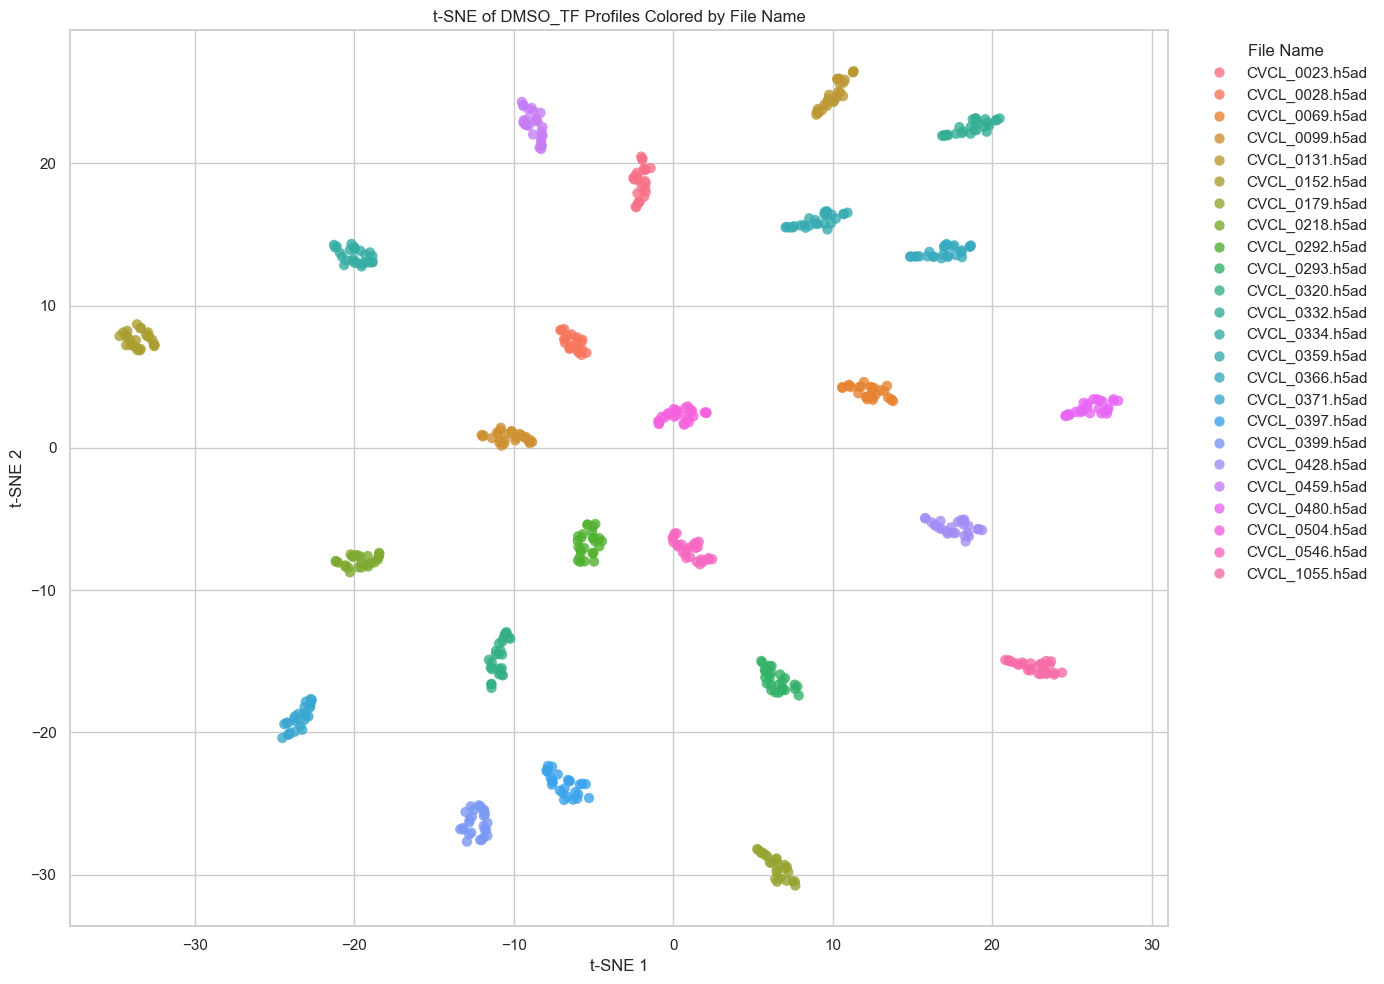

Rendered DMSO_TF t-SNE using backend: seaborn


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
dmso_tf_plot_palette = sns.color_palette("husl", n_colors=dmso_tf_tsne_df["file_name"].nunique())

fig, ax = plt.subplots(figsize=(14, 10))
sns.scatterplot(
    data=dmso_tf_tsne_df,
    x="tsne_1",
    y="tsne_2",
    hue="file_name",
    palette=dmso_tf_plot_palette,
    s=55,
    alpha=0.8,
    linewidth=0,
    ax=ax,
)

ax.set_title("t-SNE of DMSO_TF Profiles Colored by File Name")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="File Name", frameon=False)
fig.tight_layout()
plt.show()

print("Rendered DMSO_TF t-SNE using backend: seaborn")


## t-SNE Of All Conditions In One File

This view uses the same `selected_filtered_file` from above, computes a t-SNE across all conditions in that file, colors points by `drug`, and highlights the `DMSO_TF` rows with larger outlined markers.

In [15]:
selected_file_all_conditions_adata = selected_filtered_adata.copy()
selected_file_all_conditions_obs_df = selected_file_all_conditions_adata.obs.reset_index().copy()
selected_file_all_conditions_obs_df["drug"] = selected_file_all_conditions_obs_df["drug"].astype(str)
selected_file_all_conditions_obs_df["is_dmso_tf"] = selected_file_all_conditions_obs_df["drug"].eq("DMSO_TF")

selected_file_all_conditions_matrix = selected_file_all_conditions_adata.X
if hasattr(selected_file_all_conditions_matrix, "toarray"):
    selected_file_all_conditions_matrix = selected_file_all_conditions_matrix.toarray()
else:
    selected_file_all_conditions_matrix = np.asarray(selected_file_all_conditions_matrix)

selected_file_all_conditions_pca_components = min(
    50,
    selected_file_all_conditions_matrix.shape[0],
    selected_file_all_conditions_matrix.shape[1],
)
selected_file_all_conditions_perplexity = min(
    30,
    max(5, (selected_file_all_conditions_matrix.shape[0] - 1) // 3),
)

selected_file_all_conditions_pca = PCA(
    n_components=selected_file_all_conditions_pca_components,
    random_state=42,
)
selected_file_all_conditions_pca_matrix = selected_file_all_conditions_pca.fit_transform(
    selected_file_all_conditions_matrix
)

selected_file_all_conditions_tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=selected_file_all_conditions_perplexity,
    random_state=42,
)
selected_file_all_conditions_embedding = selected_file_all_conditions_tsne.fit_transform(
    selected_file_all_conditions_pca_matrix
)

selected_file_all_conditions_tsne_df = selected_file_all_conditions_obs_df.copy()
selected_file_all_conditions_tsne_df["pca_1"] = selected_file_all_conditions_pca_matrix[:, 0]
selected_file_all_conditions_tsne_df["pca_2"] = selected_file_all_conditions_pca_matrix[:, 1]
selected_file_all_conditions_tsne_df["tsne_1"] = selected_file_all_conditions_embedding[:, 0]
selected_file_all_conditions_tsne_df["tsne_2"] = selected_file_all_conditions_embedding[:, 1]

selected_file_all_conditions_summary_df = pd.DataFrame(
    {
        "value": [
            selected_filtered_file,
            int(selected_file_all_conditions_tsne_df.shape[0]),
            int(selected_file_all_conditions_tsne_df["drug"].nunique()),
            int(selected_file_all_conditions_tsne_df["is_dmso_tf"].sum()),
            selected_file_all_conditions_pca_components,
            selected_file_all_conditions_perplexity,
        ]
    },
    index=[
        "selected_file",
        "n_conditions",
        "n_unique_drugs",
        "n_dmso_tf_rows",
        "pca_components",
        "tsne_perplexity",
    ],
)

display(selected_file_all_conditions_summary_df)
display(selected_file_all_conditions_tsne_df.head())


,value
selected_file,CVCL_0023.h5ad
n_conditions,1233
n_unique_drugs,380
n_dmso_tf_rows,26
pca_components,50
tsne_perplexity,30


,pseudobulk_group,drug,drugname_drugconc,sample,plate,replicate_id,n_cells_total,n_complete_blocks,n_cells_used,n_cells_dropped,is_dmso_tf,pca_1,pca_2,tsne_1,tsne_2
0,"drug=[('(R)-Verapamil (hydrochloride)', 0.05, ...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 0.05, 'uM')]",smp_1799,plate4,smp_1799,2668,13,2668,0,False,1348.731445,1084.082031,18.538586,22.513069
1,"drug=[('(R)-Verapamil (hydrochloride)', 0.5, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 0.5, 'uM')]",smp_1895,plate5,smp_1895,1503,7,1503,0,False,-1279.750854,1041.887817,-6.013052,29.596012
2,"drug=[('(R)-Verapamil (hydrochloride)', 5.0, '...",(R)-Verapamil (hydrochloride),"[('(R)-Verapamil (hydrochloride)', 5.0, 'uM')]",smp_1991,plate6,smp_1991,2350,11,2350,0,False,1428.750366,637.742371,26.229734,21.581871
3,"drug=[('(S)-Crizotinib', 0.05, 'uM')]|sample=s...",(S)-Crizotinib,"[('(S)-Crizotinib', 0.05, 'uM')]",smp_2100,plate7,smp_2100,2396,11,2396,0,False,-1374.058716,-409.267181,-29.798220,-13.625647
4,"drug=[('(S)-Crizotinib', 0.5, 'uM')]|sample=sm...",(S)-Crizotinib,"[('(S)-Crizotinib', 0.5, 'uM')]",smp_2196,plate8,smp_2196,2203,11,2203,0,False,-197.371552,52.556931,-1.055167,-6.729300


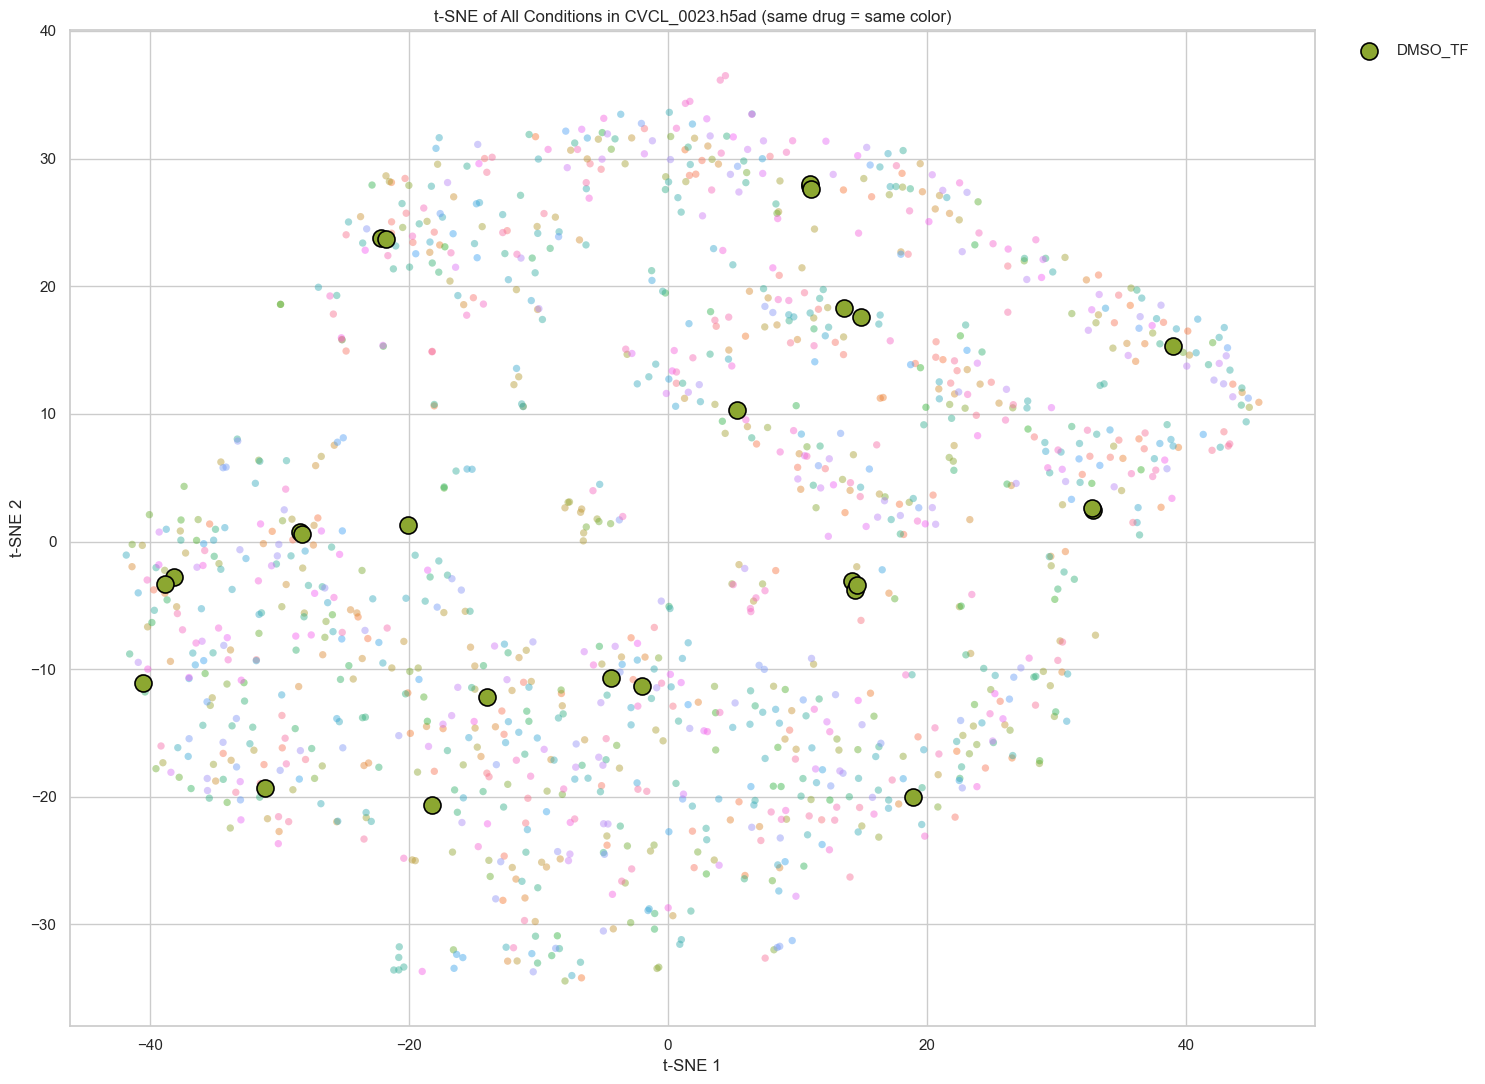

Rendered all-condition t-SNE for CVCL_0023.h5ad with DMSO_TF highlighted.


In [16]:
selected_file_all_conditions_unique_drugs = sorted(
    selected_file_all_conditions_tsne_df["drug"].unique()
)
selected_file_all_conditions_palette = dict(
    zip(
        selected_file_all_conditions_unique_drugs,
        sns.color_palette("husl", n_colors=len(selected_file_all_conditions_unique_drugs)),
    )
)

selected_file_dmso_tf_tsne_df = selected_file_all_conditions_tsne_df.loc[
    selected_file_all_conditions_tsne_df["is_dmso_tf"]
].copy()

fig, ax = plt.subplots(figsize=(15, 11))
sns.scatterplot(
    data=selected_file_all_conditions_tsne_df,
    x="tsne_1",
    y="tsne_2",
    hue="drug",
    palette=selected_file_all_conditions_palette,
    s=28,
    alpha=0.45,
    linewidth=0,
    legend=False,
    ax=ax,
)

sns.scatterplot(
    data=selected_file_dmso_tf_tsne_df,
    x="tsne_1",
    y="tsne_2",
    color=selected_file_all_conditions_palette["DMSO_TF"],
    s=150,
    edgecolor="black",
    linewidth=1.2,
    marker="o",
    label="DMSO_TF",
    ax=ax,
)

ax.set_title(
    f"t-SNE of All Conditions in {selected_filtered_file} (same drug = same color)"
)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
fig.tight_layout()
plt.show()

print(
    f"Rendered all-condition t-SNE for {selected_filtered_file} with DMSO_TF highlighted."
)


## Plate Diagnostics For The Selected File

These blocks reuse the same `selected_filtered_file` and `selected_filtered_adata` from above. The first view recolors the all-condition t-SNE by `plate`, and the second isolates `DMSO_TF` only so you can judge whether the control spread is aligning with plate structure.

In [17]:
selected_file_plate_pca_df = selected_file_all_conditions_tsne_df.copy()
selected_file_plate_pca_df["plate"] = selected_file_plate_pca_df["plate"].astype(str)

selected_file_plate_diagnostic_summary_df = pd.DataFrame(
    {
        "value": [
            selected_filtered_file,
            int(selected_file_plate_pca_df.shape[0]),
            int(selected_file_plate_pca_df["plate"].nunique()),
            int(selected_file_plate_pca_df["is_dmso_tf"].sum()),
            int(
                selected_file_plate_pca_df.loc[
                    selected_file_plate_pca_df["is_dmso_tf"], "plate"
                ].nunique()
            ),
        ]
    },
    index=[
        "selected_file",
        "n_profiles",
        "n_plates",
        "n_dmso_tf_rows",
        "n_dmso_tf_plates",
    ],
)

selected_file_profiles_by_plate_df = (
    selected_file_plate_pca_df.groupby("plate")
    .agg(
        total_profiles=("plate", "size"),
        dmso_tf_profiles=("is_dmso_tf", "sum"),
    )
    .reset_index()
    .sort_values("plate")
)

display(selected_file_plate_diagnostic_summary_df)
display(selected_file_profiles_by_plate_df)


,value
selected_file,CVCL_0023.h5ad
n_profiles,1233
n_plates,13
n_dmso_tf_rows,26
n_dmso_tf_plates,13


,plate,total_profiles,dmso_tf_profiles
0,plate1,86,2
1,plate10,96,2
2,plate11,96,2
3,plate12,96,2
4,plate13,96,2
5,plate2,92,2
6,plate3,96,2
7,plate4,96,2
8,plate5,96,2
9,plate6,96,2


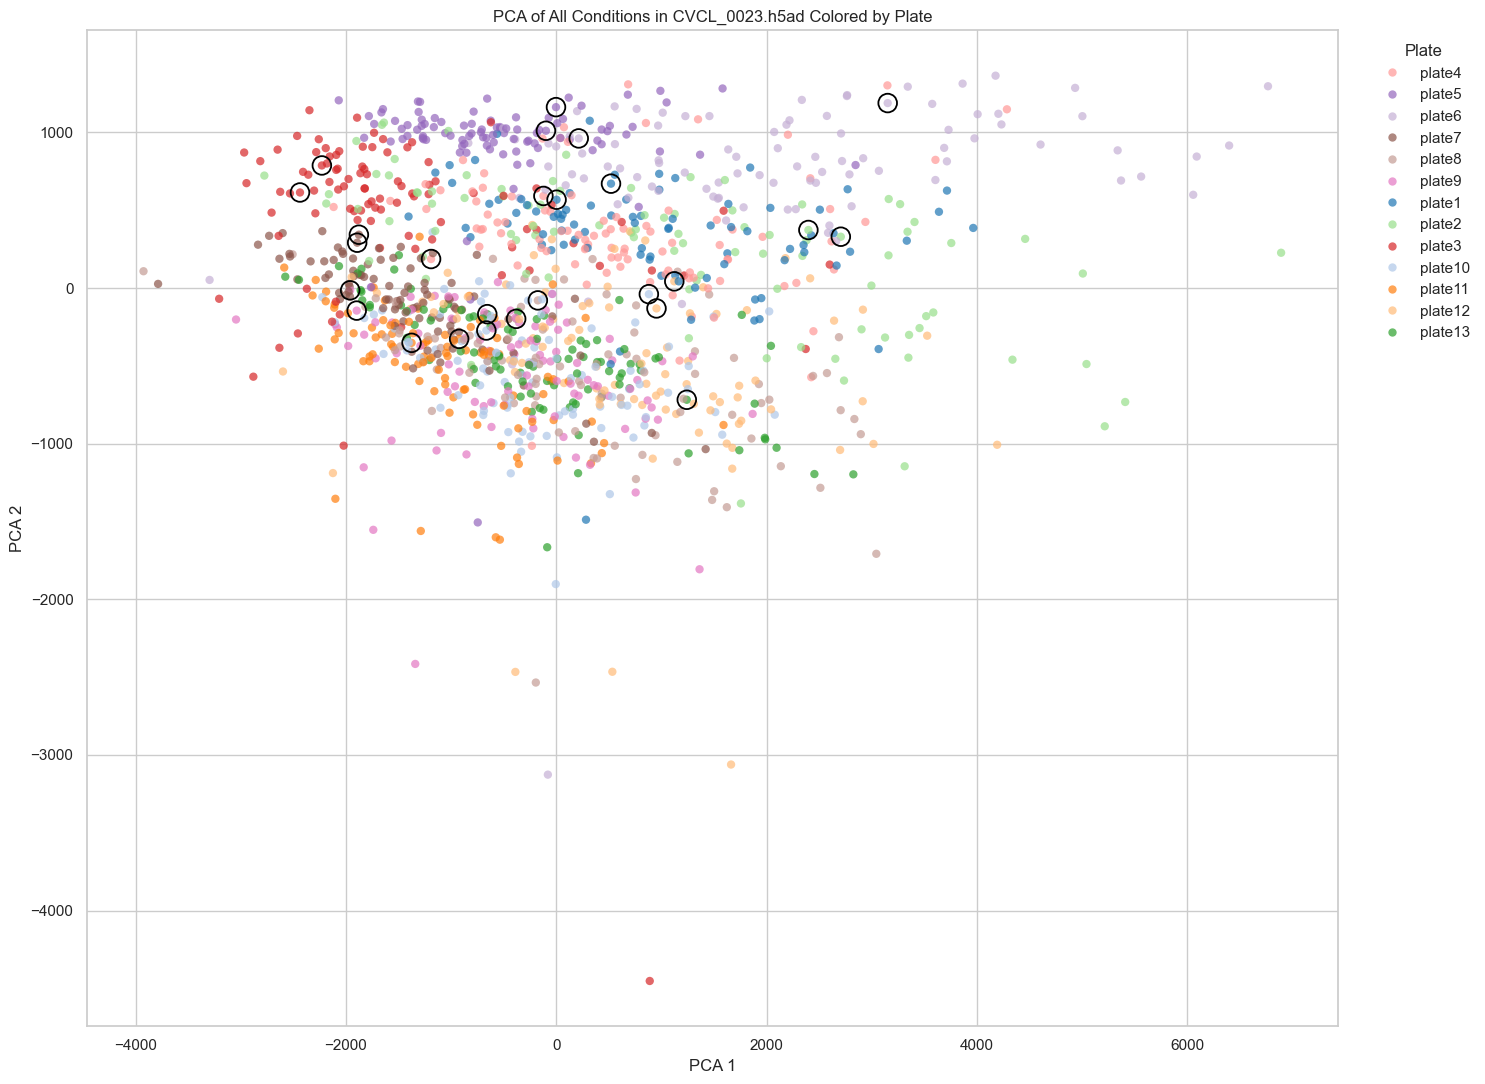

Rendered plate-colored all-condition PCA for CVCL_0023.h5ad.


In [18]:
selected_file_plate_palette = dict(
    zip(
        sorted(selected_file_plate_pca_df["plate"].unique()),
        sns.color_palette("tab20", n_colors=selected_file_plate_pca_df["plate"].nunique()),
    )
)

fig, ax = plt.subplots(figsize=(15, 11))
sns.scatterplot(
    data=selected_file_plate_pca_df,
    x="pca_1",
    y="pca_2",
    hue="plate",
    palette=selected_file_plate_palette,
    s=36,
    alpha=0.7,
    linewidth=0,
    ax=ax,
)

ax.scatter(
    selected_file_dmso_tf_tsne_df["pca_1"],
    selected_file_dmso_tf_tsne_df["pca_2"],
    s=180,
    facecolors="none",
    edgecolors="black",
    linewidths=1.3,
    label="DMSO_TF outline",
)

ax.set_title(f"PCA of All Conditions in {selected_filtered_file} Colored by Plate")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="Plate", frameon=False)
fig.tight_layout()
plt.show()

print(f"Rendered plate-colored all-condition PCA for {selected_filtered_file}.")


In [19]:
selected_file_dmso_tf_only_adata = selected_filtered_adata[
    selected_filtered_adata.obs["drug"].astype(str).eq("DMSO_TF")
].copy()

if selected_file_dmso_tf_only_adata.n_obs < 3:
    raise ValueError("Need at least 3 DMSO_TF profiles to compute DMSO_TF-only diagnostics.")

selected_file_dmso_tf_only_obs_df = selected_file_dmso_tf_only_adata.obs.reset_index().copy()
selected_file_dmso_tf_only_obs_df["plate"] = selected_file_dmso_tf_only_obs_df["plate"].astype(str)

selected_file_dmso_tf_only_matrix = selected_file_dmso_tf_only_adata.X
if hasattr(selected_file_dmso_tf_only_matrix, "toarray"):
    selected_file_dmso_tf_only_matrix = selected_file_dmso_tf_only_matrix.toarray()
else:
    selected_file_dmso_tf_only_matrix = np.asarray(selected_file_dmso_tf_only_matrix)

selected_file_dmso_tf_only_pca_components = min(
    10,
    selected_file_dmso_tf_only_matrix.shape[0],
    selected_file_dmso_tf_only_matrix.shape[1],
)
selected_file_dmso_tf_only_perplexity = min(
    10,
    max(3, (selected_file_dmso_tf_only_matrix.shape[0] - 1) // 3),
)

selected_file_dmso_tf_only_pca = PCA(
    n_components=selected_file_dmso_tf_only_pca_components,
    random_state=42,
)
selected_file_dmso_tf_only_pca_matrix = selected_file_dmso_tf_only_pca.fit_transform(
    selected_file_dmso_tf_only_matrix
)

selected_file_dmso_tf_only_tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=selected_file_dmso_tf_only_perplexity,
    random_state=42,
)
selected_file_dmso_tf_only_embedding = selected_file_dmso_tf_only_tsne.fit_transform(
    selected_file_dmso_tf_only_pca_matrix
)

selected_file_dmso_tf_only_embedding_df = selected_file_dmso_tf_only_obs_df.copy()
selected_file_dmso_tf_only_embedding_df["pca_1"] = selected_file_dmso_tf_only_pca_matrix[:, 0]
selected_file_dmso_tf_only_embedding_df["pca_2"] = selected_file_dmso_tf_only_pca_matrix[:, 1]
selected_file_dmso_tf_only_embedding_df["tsne_1"] = selected_file_dmso_tf_only_embedding[:, 0]
selected_file_dmso_tf_only_embedding_df["tsne_2"] = selected_file_dmso_tf_only_embedding[:, 1]

def summarize_plate_distances(embedding_df, coord_columns, plate_column="plate"):
    coords = embedding_df.loc[:, list(coord_columns)].to_numpy()
    plates = embedding_df[plate_column].to_numpy()
    distance_matrix = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)
    np.fill_diagonal(distance_matrix, np.inf)
    nearest_neighbor_indices = distance_matrix.argmin(axis=1)
    same_plate_nearest_neighbor_fraction = float(
        (plates == plates[nearest_neighbor_indices]).mean()
    )

    same_plate_distances = []
    between_plate_distances = []
    for i in range(coords.shape[0]):
        for j in range(i + 1, coords.shape[0]):
            distance = float(np.linalg.norm(coords[i] - coords[j]))
            if plates[i] == plates[j]:
                same_plate_distances.append(distance)
            else:
                between_plate_distances.append(distance)

    same_plate_distances = pd.Series(same_plate_distances, dtype=float)
    between_plate_distances = pd.Series(between_plate_distances, dtype=float)
    return pd.Series(
        {
            "same_plate_pairs": int(same_plate_distances.size),
            "between_plate_pairs": int(between_plate_distances.size),
            "same_plate_median_distance": float(same_plate_distances.median()),
            "between_plate_median_distance": float(between_plate_distances.median()),
            "same_plate_mean_distance": float(same_plate_distances.mean()),
            "between_plate_mean_distance": float(between_plate_distances.mean()),
            "same_plate_nearest_neighbor_fraction": same_plate_nearest_neighbor_fraction,
        }
    )

selected_file_dmso_tf_only_summary_df = pd.DataFrame(
    {
        "value": [
            selected_filtered_file,
            int(selected_file_dmso_tf_only_embedding_df.shape[0]),
            int(selected_file_dmso_tf_only_embedding_df["plate"].nunique()),
            selected_file_dmso_tf_only_pca_components,
            selected_file_dmso_tf_only_perplexity,
        ]
    },
    index=[
        "selected_file",
        "n_dmso_tf_profiles",
        "n_dmso_tf_plates",
        "pca_components",
        "tsne_perplexity",
    ],
)

selected_file_dmso_tf_only_counts_by_plate_df = (
    selected_file_dmso_tf_only_embedding_df["plate"]
    .value_counts()
    .sort_index()
    .rename_axis("plate")
    .reset_index(name="dmso_tf_count")
)

selected_file_dmso_tf_only_metrics_df = pd.concat(
    [
        summarize_plate_distances(
            selected_file_dmso_tf_only_embedding_df,
            ["pca_1", "pca_2"],
        ).rename("PCA"),
        summarize_plate_distances(
            selected_file_dmso_tf_only_embedding_df,
            ["tsne_1", "tsne_2"],
        ).rename("tSNE"),
    ],
    axis=1,
).round(3)

display(selected_file_dmso_tf_only_summary_df)
display(selected_file_dmso_tf_only_counts_by_plate_df)
display(selected_file_dmso_tf_only_metrics_df)


,value
selected_file,CVCL_0023.h5ad
n_dmso_tf_profiles,26
n_dmso_tf_plates,13
pca_components,10
tsne_perplexity,8


,plate,dmso_tf_count
0,plate1,2
1,plate10,2
2,plate11,2
3,plate12,2
4,plate13,2
5,plate2,2
6,plate3,2
7,plate4,2
8,plate5,2
9,plate6,2


,PCA,tSNE
same_plate_pairs,13.000,13.000
between_plate_pairs,312.000,312.000
same_plate_median_distance,328.529,5.011
between_plate_median_distance,1874.752,25.181
same_plate_mean_distance,769.413,11.490
between_plate_mean_distance,2037.458,27.815
same_plate_nearest_neighbor_fraction,0.577,0.654


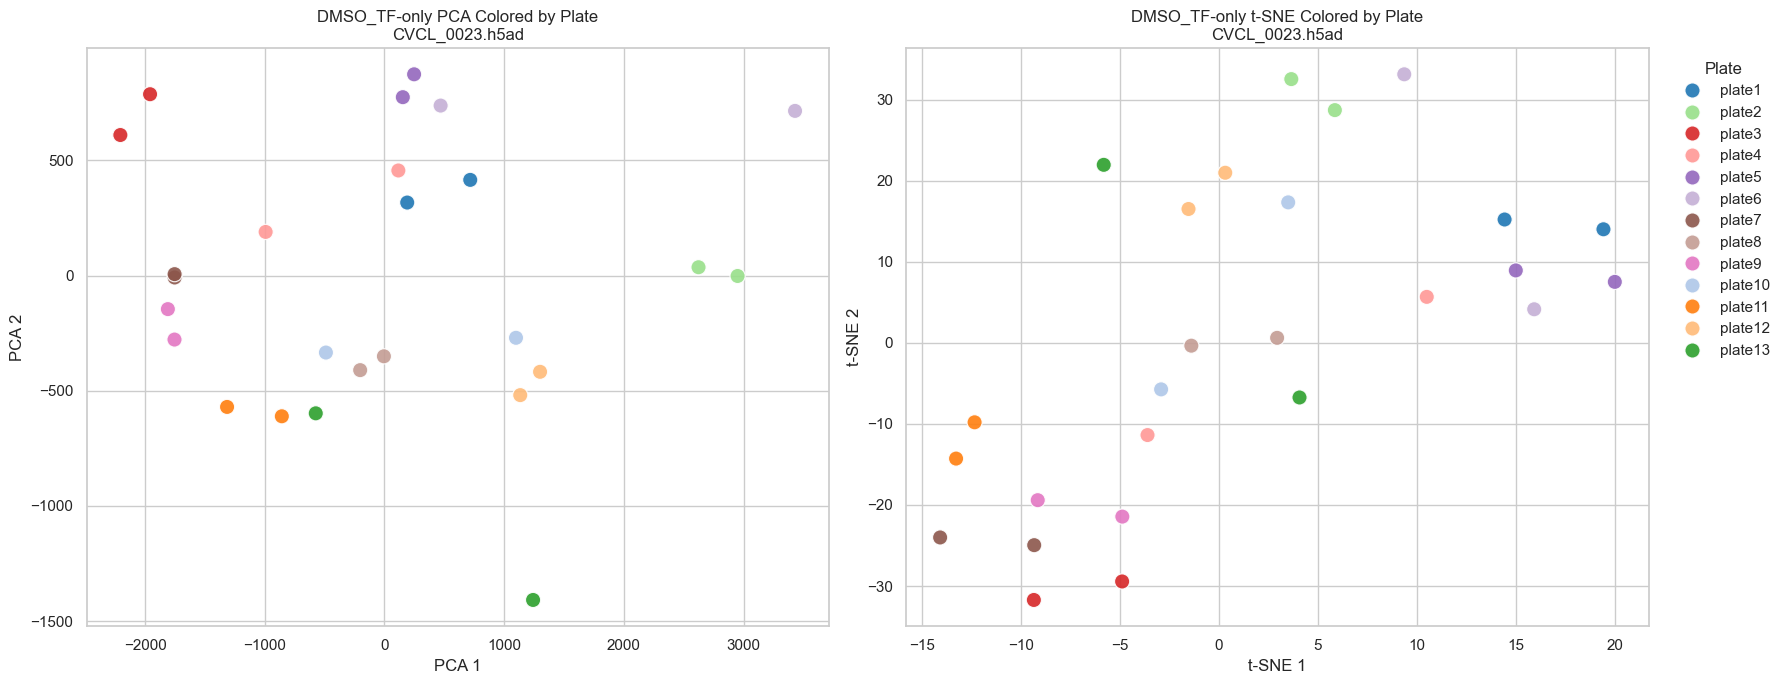

Rendered DMSO_TF-only PCA and t-SNE plate diagnostics for CVCL_0023.h5ad.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_specs = [
    (axes[0], "pca_1", "pca_2", "PCA 1", "PCA 2", "DMSO_TF-only PCA", False),
    (axes[1], "tsne_1", "tsne_2", "t-SNE 1", "t-SNE 2", "DMSO_TF-only t-SNE", True),
]

for axis, x_col, y_col, x_label, y_label, title, show_legend in plot_specs:
    sns.scatterplot(
        data=selected_file_dmso_tf_only_embedding_df,
        x=x_col,
        y=y_col,
        hue="plate",
        palette=selected_file_plate_palette,
        s=120,
        alpha=0.9,
        ax=axis,
        legend=show_legend,
    )
    axis.set_title(f"{title} Colored by Plate\n{selected_filtered_file}")
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)

if axes[1].legend_ is not None:
    sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1.02, 1), title="Plate", frameon=False)

fig.tight_layout()
plt.show()

print(f"Rendered DMSO_TF-only PCA and t-SNE plate diagnostics for {selected_filtered_file}.")


## Variance Explained By Principal Components

This block uses the same `selected_file_all_conditions_pca` object from the selected-file PCA above and shows both the variance explained by each component and the cumulative variance captured as more components are added.

,principal_component,explained_variance_ratio,explained_variance_percent,cumulative_explained_variance_percent
0,1,0.574707,57.470692,57.470692
1,2,0.104212,10.421195,67.891884
2,3,0.057411,5.741115,73.632996
3,4,0.034381,3.438110,77.071106
4,5,0.030798,3.079777,80.150887
5,6,0.022426,2.242571,82.393456
6,7,0.015194,1.519350,83.912804
7,8,0.013312,1.331228,85.244034
8,9,0.012236,1.223573,86.467606
9,10,0.010555,1.055476,87.523079


,variance_target_percent,principal_components_needed
0,80,5
1,90,13
2,95,30


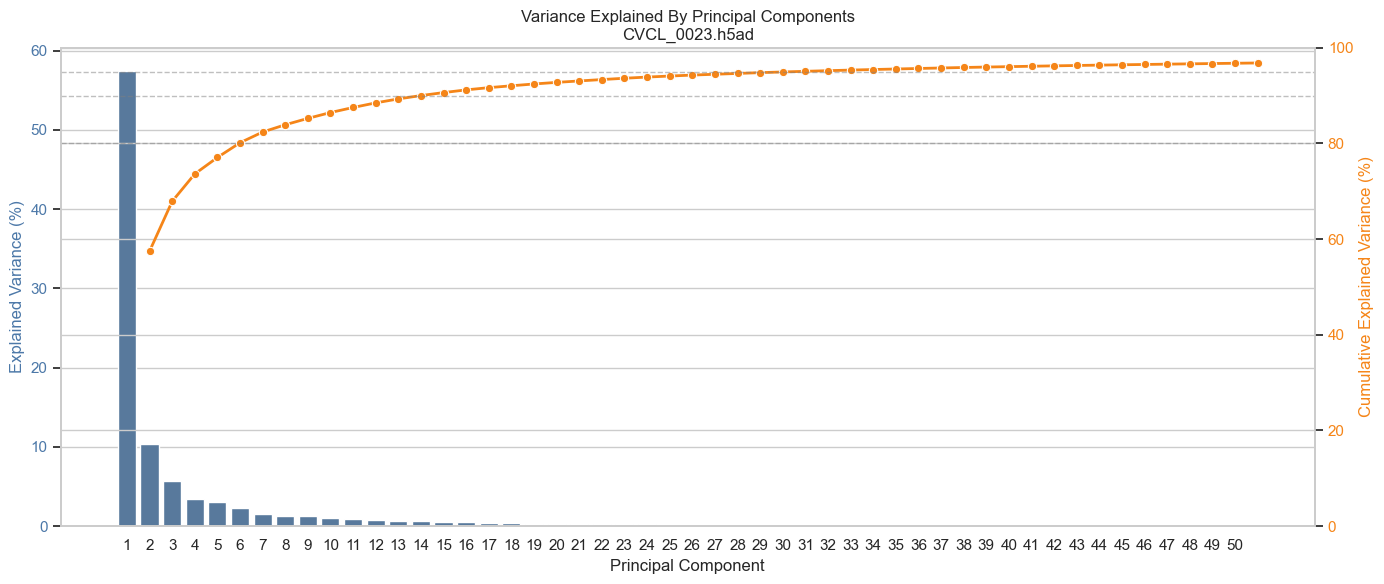

Rendered PCA variance-explained plot for CVCL_0023.h5ad.


In [21]:
selected_file_pca_variance_df = pd.DataFrame(
    {
        "principal_component": np.arange(
            1,
            selected_file_all_conditions_pca.n_components_ + 1,
        ),
        "explained_variance_ratio": selected_file_all_conditions_pca.explained_variance_ratio_,
    }
)
selected_file_pca_variance_df["explained_variance_percent"] = (
    100 * selected_file_pca_variance_df["explained_variance_ratio"]
)
selected_file_pca_variance_df["cumulative_explained_variance_percent"] = (
    selected_file_pca_variance_df["explained_variance_percent"].cumsum()
)

selected_file_pca_variance_thresholds_df = pd.DataFrame(
    {
        "variance_target_percent": [80, 90, 95],
        "principal_components_needed": [
            int(
                selected_file_pca_variance_df.loc[
                    selected_file_pca_variance_df[
                        "cumulative_explained_variance_percent"
                    ].ge(target),
                    "principal_component",
                ].iloc[0]
            )
            for target in [80, 90, 95]
        ],
    }
)

display(selected_file_pca_variance_df)
display(selected_file_pca_variance_thresholds_df)

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=selected_file_pca_variance_df,
    x="principal_component",
    y="explained_variance_percent",
    color="#4C78A8",
    ax=ax1,
)
ax1.set_title(
    f"Variance Explained By Principal Components\n{selected_filtered_file}"
)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)", color="#4C78A8")
ax1.tick_params(axis="y", labelcolor="#4C78A8")

ax2 = ax1.twinx()
sns.lineplot(
    data=selected_file_pca_variance_df,
    x="principal_component",
    y="cumulative_explained_variance_percent",
    marker="o",
    color="#F58518",
    linewidth=2,
    ax=ax2,
)
ax2.set_ylabel("Cumulative Explained Variance (%)", color="#F58518")
ax2.tick_params(axis="y", labelcolor="#F58518")
ax2.set_ylim(0, 100)
for threshold in [80, 90, 95]:
    ax2.axhline(threshold, linestyle="--", linewidth=1, color="gray", alpha=0.5)

fig.tight_layout()
plt.show()

print(f"Rendered PCA variance-explained plot for {selected_filtered_file}.")


# Save files for 20k genes

In [22]:
from datetime import datetime

project_root_candidates = [Path.cwd(), Path.cwd().parent]
project_root = next(
    (
        candidate
        for candidate in project_root_candidates
        if (candidate / "data").exists()
    ),
    Path.cwd(),
)

processed_data_parent_dir = project_root / "data"
base_processed_output_dir = processed_data_parent_dir / "Tahoe100M_Pseudobulk_processed"
base_output_dir_already_existed = base_processed_output_dir.exists()
run_date_suffix = datetime.now().strftime("%Y%m%d")
run_timestamp_suffix = datetime.now().strftime("%Y%m%d_%H%M%S")

if base_output_dir_already_existed:
    processed_output_dir = processed_data_parent_dir / f"{base_processed_output_dir.name}_{run_date_suffix}"
    if processed_output_dir.exists():
        processed_output_dir = processed_data_parent_dir / f"{base_processed_output_dir.name}_{run_timestamp_suffix}"
        collision_counter = 1
        while processed_output_dir.exists():
            processed_output_dir = processed_data_parent_dir / (
                f"{base_processed_output_dir.name}_{run_timestamp_suffix}_{collision_counter:02d}"
            )
            collision_counter += 1
else:
    processed_output_dir = base_processed_output_dir

assert len(filtered_adatas) == len(h5ad_files)
assert all(filtered_adata.n_vars == 20061 for filtered_adata in filtered_adatas.values())
processed_output_dir.mkdir(parents=True, exist_ok=False)

processed_save_records = []
for file_name, filtered_adata in sorted(filtered_adatas.items()):
    output_path = processed_output_dir / file_name
    filtered_adata.write_h5ad(output_path)
    processed_save_records.append(
        {
            "file_name": file_name,
            "output_path": str(output_path),
            "n_obs": int(filtered_adata.n_obs),
            "n_vars": int(filtered_adata.n_vars),
            "size_mb": round(output_path.stat().st_size / (1024 ** 2), 2),
        }
    )

processed_save_manifest_df = pd.DataFrame(processed_save_records)
processed_save_manifest_path = processed_output_dir / "processed_file_manifest.csv"
processed_save_manifest_df.to_csv(processed_save_manifest_path, index=False)

processed_save_summary_df = pd.DataFrame(
    {
        "value": [
            str(processed_output_dir),
            base_output_dir_already_existed,
            int(processed_save_manifest_df.shape[0]),
            int(processed_save_manifest_df["n_obs"].sum()),
            int(processed_save_manifest_df["n_vars"].iloc[0]),
            str(processed_save_manifest_path),
        ]
    },
    index=[
        "processed_output_dir",
        "base_output_dir_already_existed",
        "files_saved",
        "total_profiles_saved",
        "genes_per_file",
        "processed_save_manifest_path",
    ],
)

display(processed_save_summary_df)
display(processed_save_manifest_df)
print(f"Saved {len(processed_save_records)} processed files to {processed_output_dir}")


,value
processed_output_dir,/Users/aniruddh/Library/CloudStorage/OneDrive-...
base_output_dir_already_existed,True
files_saved,24
total_profiles_saved,29254
genes_per_file,20061
processed_save_manifest_path,/Users/aniruddh/Library/CloudStorage/OneDrive-...


,file_name,output_path,n_obs,n_vars,size_mb
0,CVCL_0023.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1233,20061,95.67
1,CVCL_0028.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1067,20061,82.93
2,CVCL_0069.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1221,20061,94.75
3,CVCL_0099.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1192,20061,92.52
4,CVCL_0131.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1232,20061,95.59
5,CVCL_0152.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1232,20061,95.59
6,CVCL_0179.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1229,20061,95.36
7,CVCL_0218.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1214,20061,94.21
8,CVCL_0292.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1199,20061,93.05
9,CVCL_0293.h5ad,/Users/aniruddh/Library/CloudStorage/OneDrive-...,1232,20061,95.59


Saved 24 processed files to /Users/aniruddh/Library/CloudStorage/OneDrive-UniversityofUtah/Marth Lab/Deep Learning_Online/deep-learning-final-project/data/Tahoe100M_Pseudobulk_processed_20260415
